In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load data
reliability_df = pd.read_csv("../../data/cross_split_metrics.csv")
quality_df = pd.read_csv("../../data/image_quality_metrics.csv")
infodump_df = pd.read_csv("../../data/raw_subject_data.csv")
subjects_df = pd.read_csv("../../data/subject.csv")
split_pair_diffs = pd.read_csv("../../data/split_comparision_data.csv")

# Merge QA metrics from raw_subject_data
def compute_qa_diff(row):
    if row['split_pair'] == 'S1-S2':
        return abs(row['QA_S1'] - row['QA_S2'])
    elif row['split_pair'] == 'S3-S4':
        return abs(row['QA_S3'] - row['QA_S4'])
    return None

def compute_qa_mean(row):
    if row['split_pair'] == 'S1-S2':
        return row['QA12_mean']
    elif row['split_pair'] == 'S3-S4':
        return row['QA34_mean']
    return None

# Add QA metrics to split_pair_diffs
qa_cols = ['subject_id', 'session_id', 'QA_S1', 'QA_S2', 'QA_S3', 'QA_S4', 'QA12_mean', 'QA34_mean']
split_pair_diffs = split_pair_diffs.merge(
    infodump_df[qa_cols],
    on=['subject_id', 'session_id'],
    how='left'
)
split_pair_diffs['QA_diff'] = split_pair_diffs.apply(compute_qa_diff, axis=1)
split_pair_diffs['QA_mean'] = split_pair_diffs.apply(compute_qa_mean, axis=1)

# Import helper functions
import sys
sys.path.insert(0, '../summary_analisys')
from _functions import (
    get_available_splits,
    get_split_data,
    get_unique_subjects,
    get_column_by_split,
    _compute_split_pair_diff,
)

In [2]:
# Data summary
print(f"Subjects found: {subjects_df['subject_id'].nunique()} subjects")
print(f"Quality data: {len(quality_df)} rows, {quality_df['subject_id'].nunique()} subjects")
print(f"  Splits available: {get_available_splits(quality_df)}")
print(f"\nQuality metrics columns:")
print(f"  {quality_df.columns.tolist()}")

# Check CNR columns
cnr_cols = [col for col in quality_df.columns if 'cnr' in col.lower()]
print(f"\nCNR columns found: {cnr_cols}")

Subjects found: 23 subjects
Quality data: 92 rows, 23 subjects
  Splits available: ['S1', 'S2', 'S3', 'S4']

Quality metrics columns:
  ['subject_id', 'session_id', 'GA', 'split', 'snr_subplate', 'snr_cortical_plate', 'snr_inner', 'cnr_sp_cp', 'cnr_sp_inner', 'cnr_cp_inner', 'sp_mean_intensity', 'sp_std_intensity', 'sp_volume_voxels', 'cp_mean_intensity', 'cp_std_intensity', 'cp_volume_voxels', 'inner_mean_intensity', 'inner_std_intensity', 'inner_volume_voxels', 'scaling_factor', 'native_vol_sp', 'native_vol_cp', 'native_vol_inner', 'wm_surface_area', 'sp_iz_cnr']

CNR columns found: ['cnr_sp_cp', 'cnr_sp_inner', 'cnr_cp_inner', 'sp_iz_cnr']


## SC1: CNR vs Gestational Age (Scatter)

/tmp/ipykernel_135267/3623860777.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  subject_cmap = plt.cm.get_cmap("tab20", n_subjects)


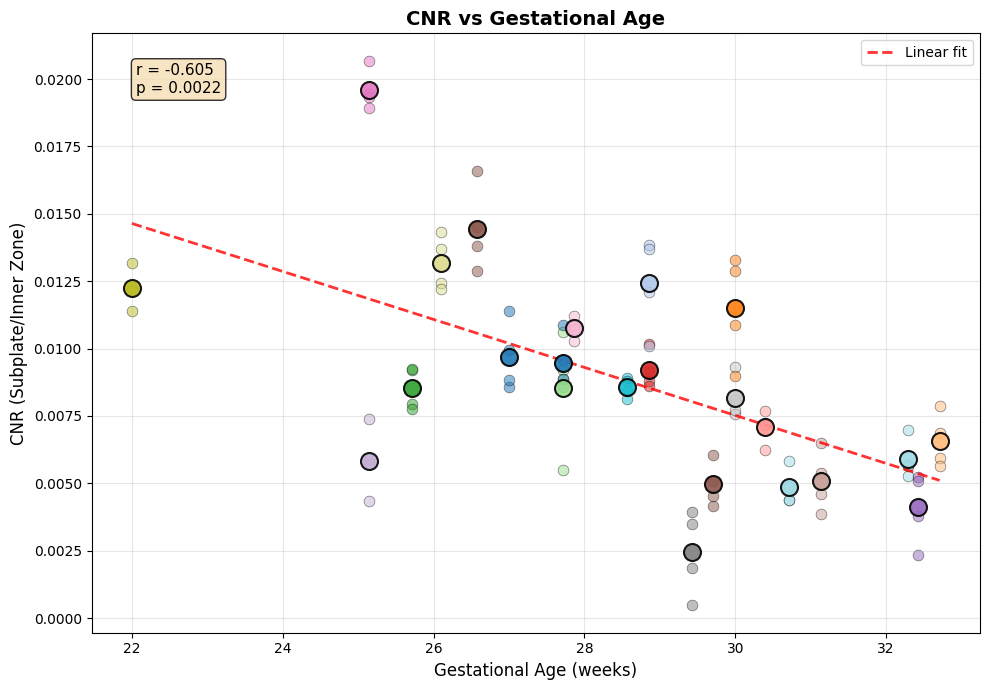

In [3]:
def plot_cnr_vs_ga_scatter(quality_df):
    """
    Scatter plot showing CNR vs Gestational Age.
    Large dots = subject mean, small dots = individual splits.
    """
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Get unique subjects for color mapping
    unique_subjects = quality_df[["subject_id", "session_id"]].drop_duplicates()
    n_subjects = len(unique_subjects)
    subject_cmap = plt.cm.get_cmap("tab20", n_subjects)

    # Create color dictionary
    subject_colors = {}
    for i, (_, row) in enumerate(unique_subjects.iterrows()):
        subject_colors[(row["subject_id"], row["session_id"])] = subject_cmap(i)

    # Group by subject and session
    grouped = quality_df.groupby(["subject_id", "session_id"])

    for (subj_id, sess_id), group in grouped:
        color = subject_colors[(subj_id, sess_id)]
        ga_values = group["GA"].values
        cnr_values = group["sp_iz_cnr"].values

        # Plot individual points (4 splits per subject)
        ax.scatter(
            ga_values,
            cnr_values,
            c=[color],
            s=60,
            alpha=0.5,
            edgecolors="black",
            linewidths=0.5,
        )

        # Plot mean as larger marker
        mean_ga = ga_values.mean()
        mean_cnr = cnr_values.mean()
        ax.scatter(
            mean_ga,
            mean_cnr,
            c=[color],
            s=150,
            alpha=0.9,
            edgecolors="black",
            linewidths=1.5,
            zorder=5,
        )

    # Calculate and display correlation using subject means
    subject_means = (
        quality_df.groupby(["subject_id", "session_id"])
        .agg({"GA": "mean", "sp_iz_cnr": "mean"})
        .dropna()
    )

    if len(subject_means) >= 3:
        r, p = stats.pearsonr(subject_means["GA"], subject_means["sp_iz_cnr"])

        # Add regression line
        z = np.polyfit(subject_means["GA"], subject_means["sp_iz_cnr"], 1)
        p_line = np.poly1d(z)
        x_line = np.linspace(subject_means["GA"].min(), subject_means["GA"].max(), 100)
        ax.plot(
            x_line, p_line(x_line), "r--", alpha=0.8, linewidth=2, label="Linear fit"
        )

        # Add correlation text box
        ax.text(
            0.05,
            0.95,
            f"r = {r:.3f}\np = {p:.4f}",
            transform=ax.transAxes,
            fontsize=11,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
        )

    ax.set_xlabel("Gestational Age (weeks)", fontsize=12)
    ax.set_ylabel("CNR (Subplate/Inner Zone)", fontsize=12)
    ax.set_title("CNR vs Gestational Age", fontsize=14, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

    plt.tight_layout()
    return fig


fig = plot_cnr_vs_ga_scatter(quality_df)
plt.show()

## SC2: CNR per Subject Across Splits

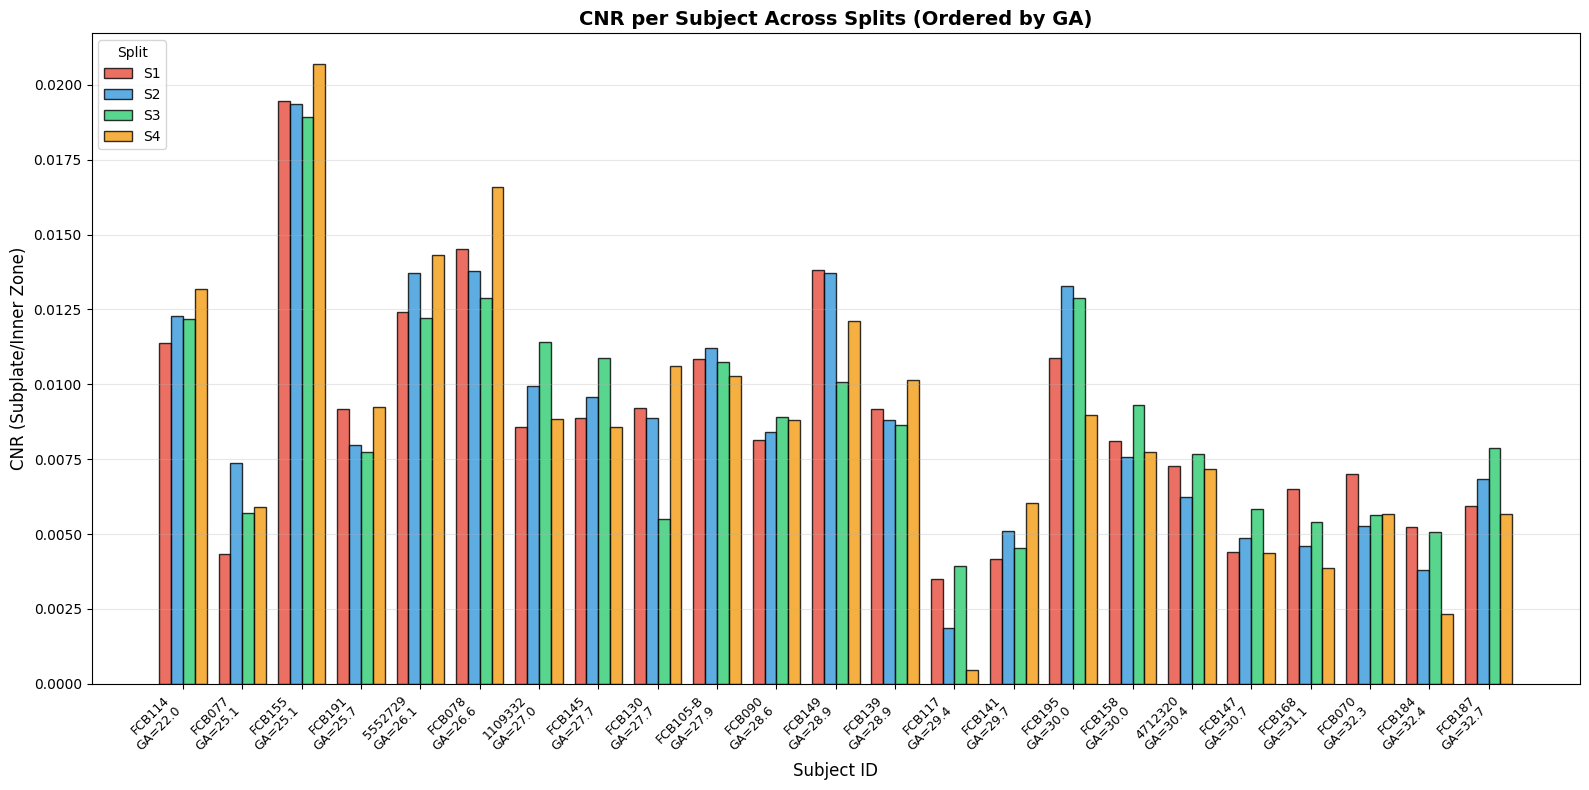

In [4]:
def plot_cnr_per_subject_by_ga(quality_df):
    """
    Bar plot showing CNR per subject across all 4 splits, ordered by GA.
    """
    subjects = get_unique_subjects(quality_df)
    splits = get_available_splits(quality_df)
    colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

    # Calculate mean GA per subject for ordering
    subject_gas = {}
    for (subj_id, ses_id) in subjects:
        rows = quality_df[
            (quality_df["subject_id"] == subj_id)
            & (quality_df["session_id"] == ses_id)
        ]
        if len(rows) > 0:
            subject_gas[(subj_id, ses_id)] = rows["GA"].iloc[0]

    # Sort subjects by GA (ascending)
    subjects_sorted = sorted(subjects, key=lambda s: subject_gas.get(s, 0))

    fig, ax = plt.subplots(figsize=(16, 8))

    x = np.arange(len(subjects_sorted))
    width = 0.2

    for i, split in enumerate(splits):
        values = []
        for (subj_id, ses_id) in subjects_sorted:
            row = get_split_data(quality_df, subj_id, ses_id, split)
            if row is not None and "sp_iz_cnr" in row.index and pd.notna(row["sp_iz_cnr"]):
                values.append(row["sp_iz_cnr"])
            else:
                values.append(np.nan)

        offset = (i - 1.5) * width
        ax.bar(
            x + offset,
            values,
            width,
            label=split,
            color=colors[i],
            alpha=0.8,
            edgecolor="black",
        )

    # Create x-tick labels with subject_id and GA
    tick_labels = [
        f"{subj}\nGA={subject_gas.get((subj, ses), 0):.1f}"
        for subj, ses in subjects_sorted
    ]

    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=9)
    ax.set_xlabel("Subject ID", fontsize=12)
    ax.set_ylabel("CNR (Subplate/Inner Zone)", fontsize=12)
    ax.set_title("CNR per Subject Across Splits (Ordered by GA)", fontsize=14, fontweight="bold")
    ax.legend(title="Split", loc="upper left")
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    return fig


fig = plot_cnr_per_subject_by_ga(quality_df)
plt.show()

## SC3: CNR by Split (Box Plot)


CNR per split:
  S1: median=0.0086, IQR=0.0047, N=23
  S2: median=0.0084, IQR=0.0060, N=23
  S3: median=0.0086, IQR=0.0055, N=23
  S4: median=0.0088, IQR=0.0047, N=23


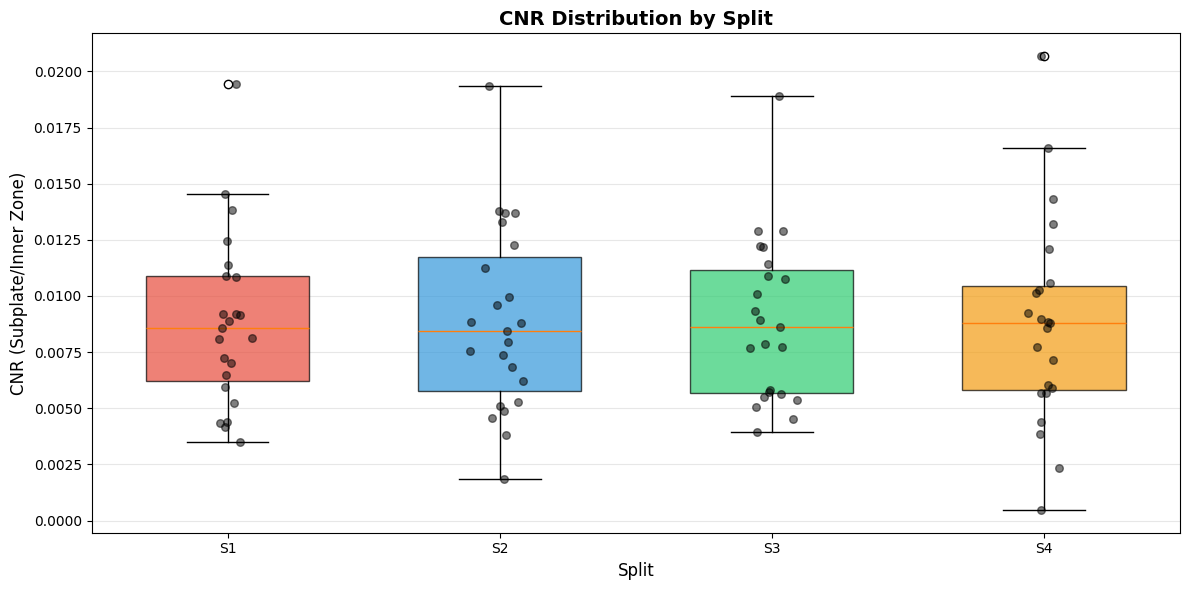

In [5]:
def plot_cnr_by_split(quality_df):
    """
    Box plot showing CNR per split.
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    splits = get_available_splits(quality_df)
    colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

    # Collect data for box plots
    split_data = []
    for split in splits:
        values = get_column_by_split(quality_df, "sp_iz_cnr", split).dropna().values
        split_data.append(values)

    if any(len(d) > 0 for d in split_data):
        bp = ax.boxplot(
            split_data, tick_labels=splits, patch_artist=True, widths=0.6
        )
        for patch, color in zip(bp["boxes"], colors[: len(splits)]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        # Add scatter points
        for i, d in enumerate(split_data):
            if len(d) > 0:
                x = np.random.normal(i + 1, 0.04, size=len(d))
                ax.scatter(x, d, alpha=0.5, s=30, color="black", zorder=3)

    ax.set_ylabel("CNR (Subplate/Inner Zone)", fontsize=12)
    ax.set_xlabel("Split", fontsize=12)
    ax.set_title("CNR Distribution by Split", fontsize=14, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")

    # Print summary statistics
    print("\nCNR per split:")
    for i, (split, data) in enumerate(zip(splits, split_data)):
        if len(data) > 0:
            med = np.median(data)
            iqr = np.percentile(data, 75) - np.percentile(data, 25)
            print(f"  {split}: median={med:.4f}, IQR={iqr:.4f}, N={len(data)}")

    plt.tight_layout()
    return fig


fig = plot_cnr_by_split(quality_df)
plt.show()

## SC4: CNR Difference vs GA (Split Pairs)

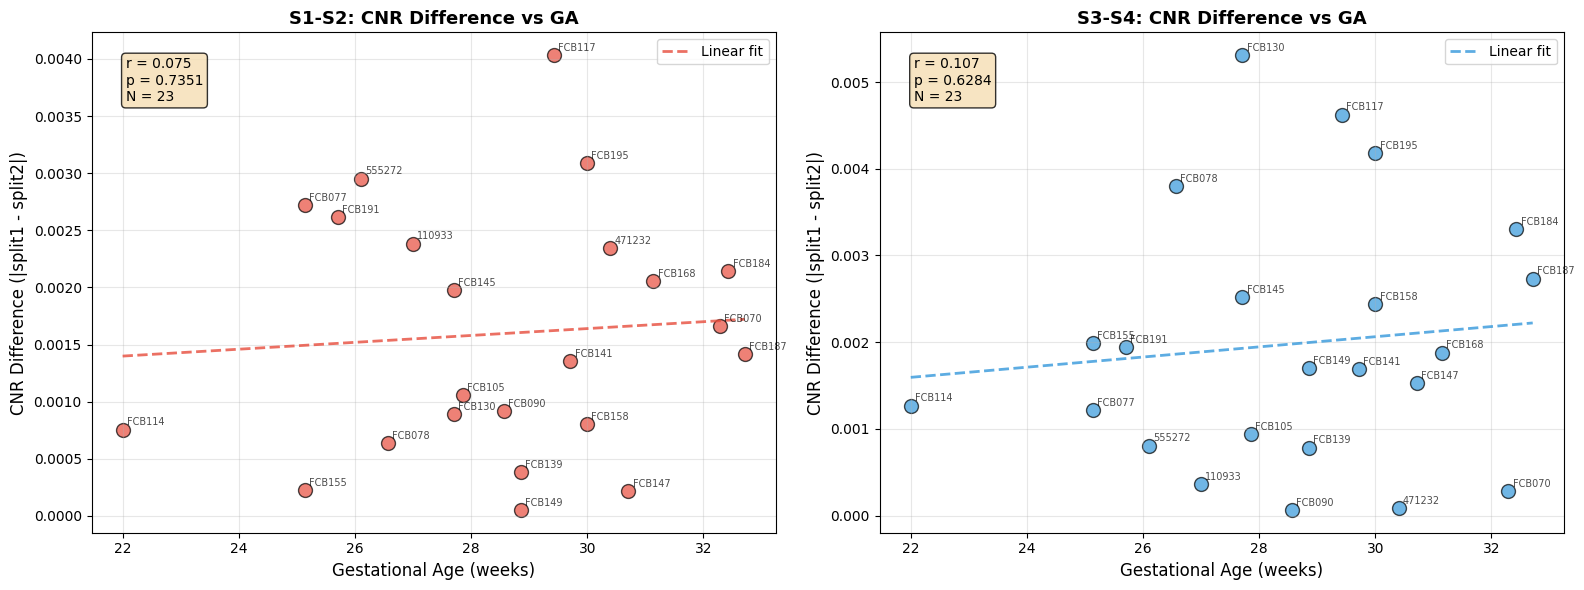

In [6]:
def plot_cnr_diff_vs_ga(split_pair_diffs):
    """
    Scatter plot showing CNR difference between split pairs vs GA.
    S1-S2 and S3-S4 are independent test-retest pairs.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    colors = {"S1-S2": "#e74c3c", "S3-S4": "#3498db"}

    for ax_idx, split_pair in enumerate(["S1-S2", "S3-S4"]):
        ax = axes[ax_idx]
        
        # Filter for this split pair
        pair_data = split_pair_diffs[split_pair_diffs["split_pair"] == split_pair].dropna(
            subset=["GA", "cnr_diff"]
        )

        if len(pair_data) < 3:
            ax.text(0.5, 0.5, f"Insufficient data for {split_pair}", 
                   ha="center", va="center", transform=ax.transAxes)
            continue

        x = pair_data["GA"].values
        y = pair_data["cnr_diff"].values

        # Scatter plot
        ax.scatter(x, y, s=100, alpha=0.7, color=colors[split_pair], edgecolors="black", linewidths=1)

        # Add subject labels
        for _, row in pair_data.iterrows():
            ax.annotate(
                str(row["subject_id"])[:6],
                (row["GA"], row["cnr_diff"]),
                fontsize=7,
                alpha=0.7,
                xytext=(3, 3),
                textcoords="offset points",
            )

        # Pearson correlation
        if len(x) >= 3:
            r, p = stats.pearsonr(x, y)
            
            # Fit line
            z = np.polyfit(x, y, 1)
            p_line = np.poly1d(z)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, p_line(x_line), "--", alpha=0.8, linewidth=2, 
                   color=colors[split_pair], label="Linear fit")

            ax.text(
                0.05,
                0.95,
                f"r = {r:.3f}\np = {p:.4f}\nN = {len(x)}",
                transform=ax.transAxes,
                fontsize=10,
                verticalalignment="top",
                bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
            )

        ax.set_xlabel("Gestational Age (weeks)", fontsize=12)
        ax.set_ylabel("CNR Difference (|split1 - split2|)", fontsize=12)
        ax.set_title(f"{split_pair}: CNR Difference vs GA", fontsize=13, fontweight="bold")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")

    plt.tight_layout()
    return fig


fig = plot_cnr_diff_vs_ga(split_pair_diffs)
plt.show()

## SNR vs CNR Comparison (Sanity Check)

Quick comparison: does SNR (like in prior analyses) correlate with reliability better than CNR?

In [7]:
# Merge SNR data from quality_df for comparison
snr_data = quality_df[['subject_id', 'session_id', 'split', 'snr_subplate']].copy()
snr_data['split_name'] = snr_data['split']

# Compute SNR diff for each split pair
snr_diffs = []
for (subj_id, sess_id), group_df in split_pair_diffs[split_pair_diffs['split_pair'] == 'S1-S2'].groupby(['subject_id', 'session_id']):
    s1 = snr_data[(snr_data['subject_id']==subj_id) & (snr_data['session_id']==sess_id) & (snr_data['split']=='S1')]
    s2 = snr_data[(snr_data['subject_id']==subj_id) & (snr_data['session_id']==sess_id) & (snr_data['split']=='S2')]
    if len(s1) > 0 and len(s2) > 0:
        snr_diff = abs(s1['snr_subplate'].values[0] - s2['snr_subplate'].values[0])
        snr_diffs.append({'subject_id': subj_id, 'split_pair': 'S1-S2', 'snr_diff': snr_diff})

for (subj_id, sess_id), group_df in split_pair_diffs[split_pair_diffs['split_pair'] == 'S3-S4'].groupby(['subject_id', 'session_id']):
    s3 = snr_data[(snr_data['subject_id']==subj_id) & (snr_data['session_id']==sess_id) & (snr_data['split']=='S3')]
    s4 = snr_data[(snr_data['subject_id']==subj_id) & (snr_data['session_id']==sess_id) & (snr_data['split']=='S4')]
    if len(s3) > 0 and len(s4) > 0:
        snr_diff = abs(s3['snr_subplate'].values[0] - s4['snr_subplate'].values[0])
        snr_diffs.append({'subject_id': subj_id, 'split_pair': 'S3-S4', 'snr_diff': snr_diff})

snr_diff_df = pd.DataFrame(snr_diffs)
split_pair_diffs = split_pair_diffs.merge(snr_diff_df, on=['subject_id', 'split_pair'], how='left')

print("SNR vs CNR correlation with surface/volume instability:")
print("\nS1-S2 Pair:")
for pair in ['S1-S2', 'S3-S4']:
    pair_data = split_pair_diffs[split_pair_diffs['split_pair']==pair].dropna(subset=['snr_diff', 'cnr_diff', 'wm_surface_area_diff'])
    if len(pair_data) >= 3:
        r_snr_surf, p_snr_surf = stats.pearsonr(pair_data['snr_diff'], pair_data['wm_surface_area_diff'])
        r_cnr_surf, p_cnr_surf = stats.pearsonr(pair_data['cnr_diff'], pair_data['wm_surface_area_diff'])
        r_snr_vol, p_snr_vol = stats.pearsonr(pair_data['snr_diff'], pair_data['abs_diff_sp'])
        r_cnr_vol, p_cnr_vol = stats.pearsonr(pair_data['cnr_diff'], pair_data['abs_diff_sp'])
        
        if pair == 'S1-S2':
            print(f"\n{pair}:")
        else:
            print(f"\n{pair}:")
        print(f"  Surface: SNR r={r_snr_surf:.3f} p={p_snr_surf:.4f} | CNR r={r_cnr_surf:.3f} p={p_cnr_surf:.4f}")
        print(f"  Volume:  SNR r={r_snr_vol:.3f} p={p_snr_vol:.4f} | CNR r={r_cnr_vol:.3f} p={p_cnr_vol:.4f}")

SNR vs CNR correlation with surface/volume instability:

S1-S2 Pair:

S1-S2:
  Surface: SNR r=-0.243 p=0.2648 | CNR r=0.281 p=0.1940
  Volume:  SNR r=0.312 p=0.1477 | CNR r=0.250 p=0.2494

S3-S4:
  Surface: SNR r=-0.168 p=0.4426 | CNR r=0.084 p=0.7015
  Volume:  SNR r=-0.264 p=0.2238 | CNR r=0.020 p=0.9295


## Exploratory: CNR Variability and Distribution


CNR within-subject variation (mean ± std across splits):
subject_id     mean      std
    FCB117 0.002439 0.001590
    FCB184 0.004107 0.001348
    FCB147 0.004865 0.000685
    FCB141 0.004959 0.000821
    FCB168 0.005082 0.001126
    FCB077 0.005831 0.001244
    FCB070 0.005900 0.000754
    FCB187 0.006583 0.000998
   4712320 0.007082 0.000609
    FCB158 0.008177 0.000796
    FCB191 0.008535 0.000797
    FCB130 0.008541 0.002160
    FCB090 0.008570 0.000353
    FCB139 0.009188 0.000683
    FCB145 0.009483 0.001015
   1109332 0.009696 0.001285
  FCB105-B 0.010777 0.000386
    FCB195 0.011514 0.001988
    FCB114 0.012255 0.000740
    FCB149 0.012427 0.001751
   5552729 0.013164 0.001010
    FCB078 0.014445 0.001571
    FCB155 0.019602 0.000758

CNR difference summary:
  S1-S2: median=0.001420, IQR=0.001585
  S3-S4: median=0.001702, IQR=0.001751


/tmp/ipykernel_135267/675550108.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([s12_cnr_diff, s34_cnr_diff], labels=['S1-S2', 'S3-S4'], patch_artist=True, widths=0.6)


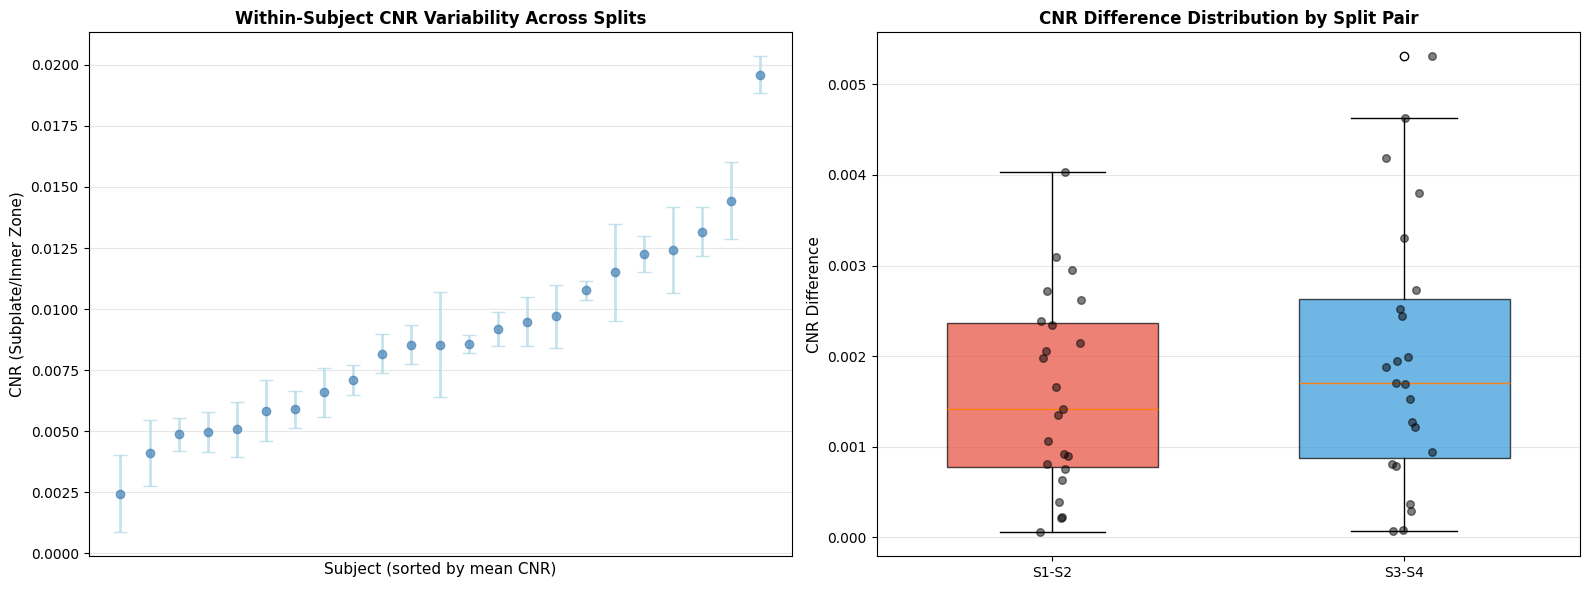

In [8]:
# Plot CNR variability within subjects across splits
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: CNR within-subject variation
ax = axes[0]
cnr_by_subj = quality_df.groupby(['subject_id', 'session_id'])['sp_iz_cnr'].agg(['mean', 'std', 'min', 'max']).reset_index()
cnr_by_subj = cnr_by_subj.sort_values('mean')
x_pos = np.arange(len(cnr_by_subj))
ax.errorbar(x_pos, cnr_by_subj['mean'], yerr=cnr_by_subj['std'], 
           fmt='o', color='steelblue', ecolor='lightblue', elinewidth=2, capsize=5, alpha=0.7)
ax.set_xlabel('Subject (sorted by mean CNR)', fontsize=11)
ax.set_ylabel('CNR (Subplate/Inner Zone)', fontsize=11)
ax.set_title('Within-Subject CNR Variability Across Splits', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticks([])

# Right: CNR difference distribution for split pairs
ax = axes[1]
s12_cnr_diff = split_pair_diffs[split_pair_diffs['split_pair']=='S1-S2']['cnr_diff'].dropna()
s34_cnr_diff = split_pair_diffs[split_pair_diffs['split_pair']=='S3-S4']['cnr_diff'].dropna()

bp = ax.boxplot([s12_cnr_diff, s34_cnr_diff], labels=['S1-S2', 'S3-S4'], patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], ['#e74c3c', '#3498db']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add scatter
for i, data in enumerate([s12_cnr_diff, s34_cnr_diff], 1):
    x = np.random.normal(i, 0.04, size=len(data))
    ax.scatter(x, data, alpha=0.5, s=30, color='black', zorder=3)

ax.set_ylabel('CNR Difference', fontsize=11)
ax.set_title('CNR Difference Distribution by Split Pair', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

print("\nCNR within-subject variation (mean ± std across splits):")
print(cnr_by_subj[['subject_id', 'mean', 'std']].to_string(index=False))

print(f"\nCNR difference summary:")
print(f"  S1-S2: median={s12_cnr_diff.median():.6f}, IQR={s12_cnr_diff.quantile(0.75)-s12_cnr_diff.quantile(0.25):.6f}")
print(f"  S3-S4: median={s34_cnr_diff.median():.6f}, IQR={s34_cnr_diff.quantile(0.75)-s34_cnr_diff.quantile(0.25):.6f}")

plt.tight_layout()
plt.show()

## Phase 2: CNR Correlation Matrix

Examine relationships between CNR, surface/volume differences, and quality metrics using FDR-corrected correlations.


S1-S2: N=23 complete cases
  Variables shape: (23, 5)
  Surface Diff vs Volume (SP) Diff: r=-0.031, p=0.8900
  Surface Diff vs CNR Diff: r=0.281, p=0.1940
  Surface Diff vs CNR Mean: r=0.058, p=0.7931
  Surface Diff vs GA: r=0.093, p=0.6715
  Volume (SP) Diff vs CNR Diff: r=0.250, p=0.2494
  Volume (SP) Diff vs CNR Mean: r=-0.112, p=0.6113
  Volume (SP) Diff vs GA: r=0.382, p=0.0722
  CNR Diff vs CNR Mean: r=-0.358, p=0.0932
  CNR Diff vs GA: r=0.075, p=0.7351
  CNR Mean vs GA: r=-0.432, p=0.0398

S3-S4: N=23 complete cases
  Variables shape: (23, 5)
  Surface Diff vs Volume (SP) Diff: r=0.331, p=0.1231
  Surface Diff vs CNR Diff: r=0.084, p=0.7015
  Surface Diff vs CNR Mean: r=-0.220, p=0.3142
  Surface Diff vs GA: r=0.434, p=0.0385
  Volume (SP) Diff vs CNR Diff: r=0.020, p=0.9295
  Volume (SP) Diff vs CNR Mean: r=-0.257, p=0.2368
  Volume (SP) Diff vs GA: r=0.603, p=0.0023
  CNR Diff vs CNR Mean: r=-0.212, p=0.3322
  CNR Diff vs GA: r=0.107, p=0.6284
  CNR Mean vs GA: r=-0.475, p=0

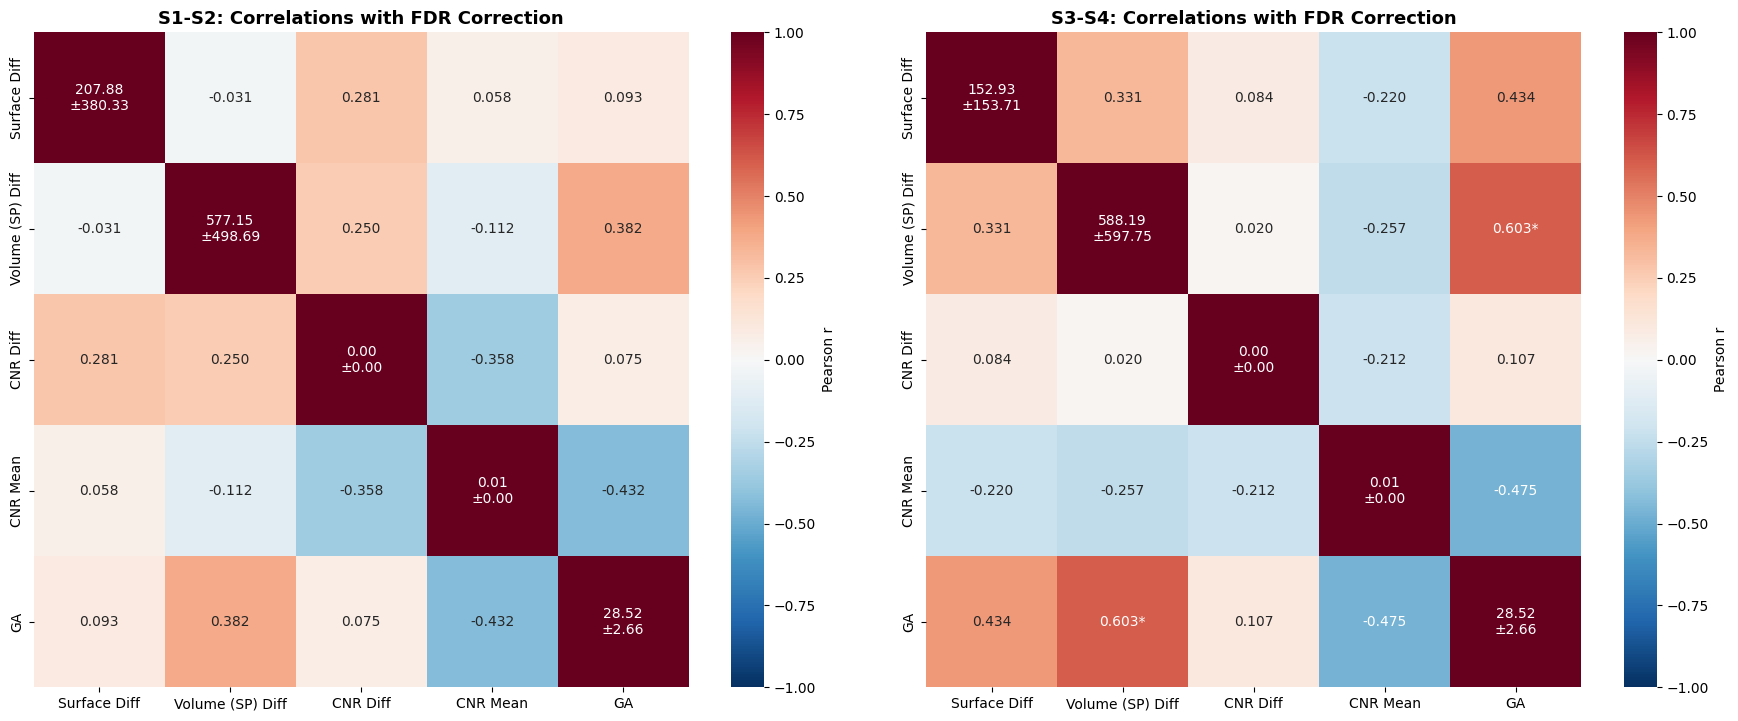

In [9]:
from statsmodels.stats.multitest import multipletests
import seaborn as sns

def plot_cnr_correlation_matrices(split_pair_diffs):
    """
    Create FDR-corrected correlation matrices for CNR analysis.
    Compares CNR differences with surface/volume reliability and GA.
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    split_pairs = ['S1-S2', 'S3-S4']
    
    # Variables to correlate: CNR diff, surface/vol diff, CNR mean, GA
    var_names = ['wm_surface_area_diff', 'abs_diff_sp', 'cnr_diff', 'cnr_mean', 'GA']
    var_labels = ['Surface Diff', 'Volume (SP) Diff', 'CNR Diff', 'CNR Mean', 'GA']
    
    for idx, split_pair in enumerate(split_pairs):
        ax = axes[idx]
        
        # Filter data for this split pair
        pair_data = split_pair_diffs[split_pair_diffs['split_pair'] == split_pair].copy()
        
        # Select variables and drop NaN
        corr_data = pair_data[var_names].dropna()
        
        print(f"\n{split_pair}: N={len(corr_data)} complete cases")
        print(f"  Variables shape: {corr_data.shape}")
        
        # Compute Pearson correlations
        n_vars = len(var_names)
        r_matrix = np.zeros((n_vars, n_vars))
        p_matrix = np.zeros((n_vars, n_vars))
        
        p_values_flat = []
        p_indices = []
        
        for i in range(n_vars):
            for j in range(i, n_vars):
                if i == j:
                    r_matrix[i, j] = 1.0
                    p_matrix[i, j] = 1.0
                else:
                    valid = ~(corr_data.iloc[:, i].isna() | corr_data.iloc[:, j].isna())
                    if valid.sum() >= 3:
                        r, p = stats.pearsonr(corr_data.iloc[valid, i], corr_data.iloc[valid, j])
                        r_matrix[i, j] = r_matrix[j, i] = r
                        p_matrix[i, j] = p_matrix[j, i] = p
                        p_values_flat.append(p)
                        p_indices.append((i, j))
                        print(f"  {var_labels[i]} vs {var_labels[j]}: r={r:.3f}, p={p:.4f}")
        
        # FDR correction
        if p_values_flat:
            _, p_fdr = multipletests(p_values_flat, method='fdr_bh')[:2]
            
            # Map back to matrix
            p_fdr_matrix = p_matrix.copy()
            for idx_p, (i, j) in enumerate(p_indices):
                p_fdr_matrix[i, j] = p_fdr_matrix[j, i] = p_fdr[idx_p]
        else:
            p_fdr_matrix = p_matrix.copy()
        
        # Create display matrix with r and significance stars
        display_matrix = np.empty((n_vars, n_vars), dtype=object)
        
        for i in range(n_vars):
            for j in range(n_vars):
                if i == j:
                    mean_val = corr_data.iloc[:, i].mean()
                    std_val = corr_data.iloc[:, i].std()
                    display_matrix[i, j] = f"{mean_val:.2f}\n±{std_val:.2f}"
                else:
                    r = r_matrix[i, j]
                    p = p_fdr_matrix[i, j]
                    
                    stars = ""
                    if p < 0.001:
                        stars = "***"
                    elif p < 0.01:
                        stars = "**"
                    elif p < 0.05:
                        stars = "*"
                    
                    display_matrix[i, j] = f"{r:.3f}{stars}"
        
        # Plot heatmap (use r_matrix for color scaling)
        sns.heatmap(
            r_matrix,
            annot=display_matrix,
            fmt='',
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            ax=ax,
            cbar_kws={'label': 'Pearson r'},
            xticklabels=var_labels,
            yticklabels=var_labels,
        )
        ax.set_title(f'{split_pair}: Correlations with FDR Correction', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    return fig


fig = plot_cnr_correlation_matrices(split_pair_diffs)
plt.show()

## Phase 3: CNR vs Surface/Volume Correlation with RANSAC

Test whether CNR differences predict surface area and volume reliability better than SNR does.

/home/yair/Projects/Reliability-analisys-FNNDSC/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/yair/Projects/Reliability-analisys-FNNDSC/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/yair/Projects/Reliability-analisys-FNNDSC/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/yair/Projects/Reliability-analisys-FNNDSC/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/yair/P

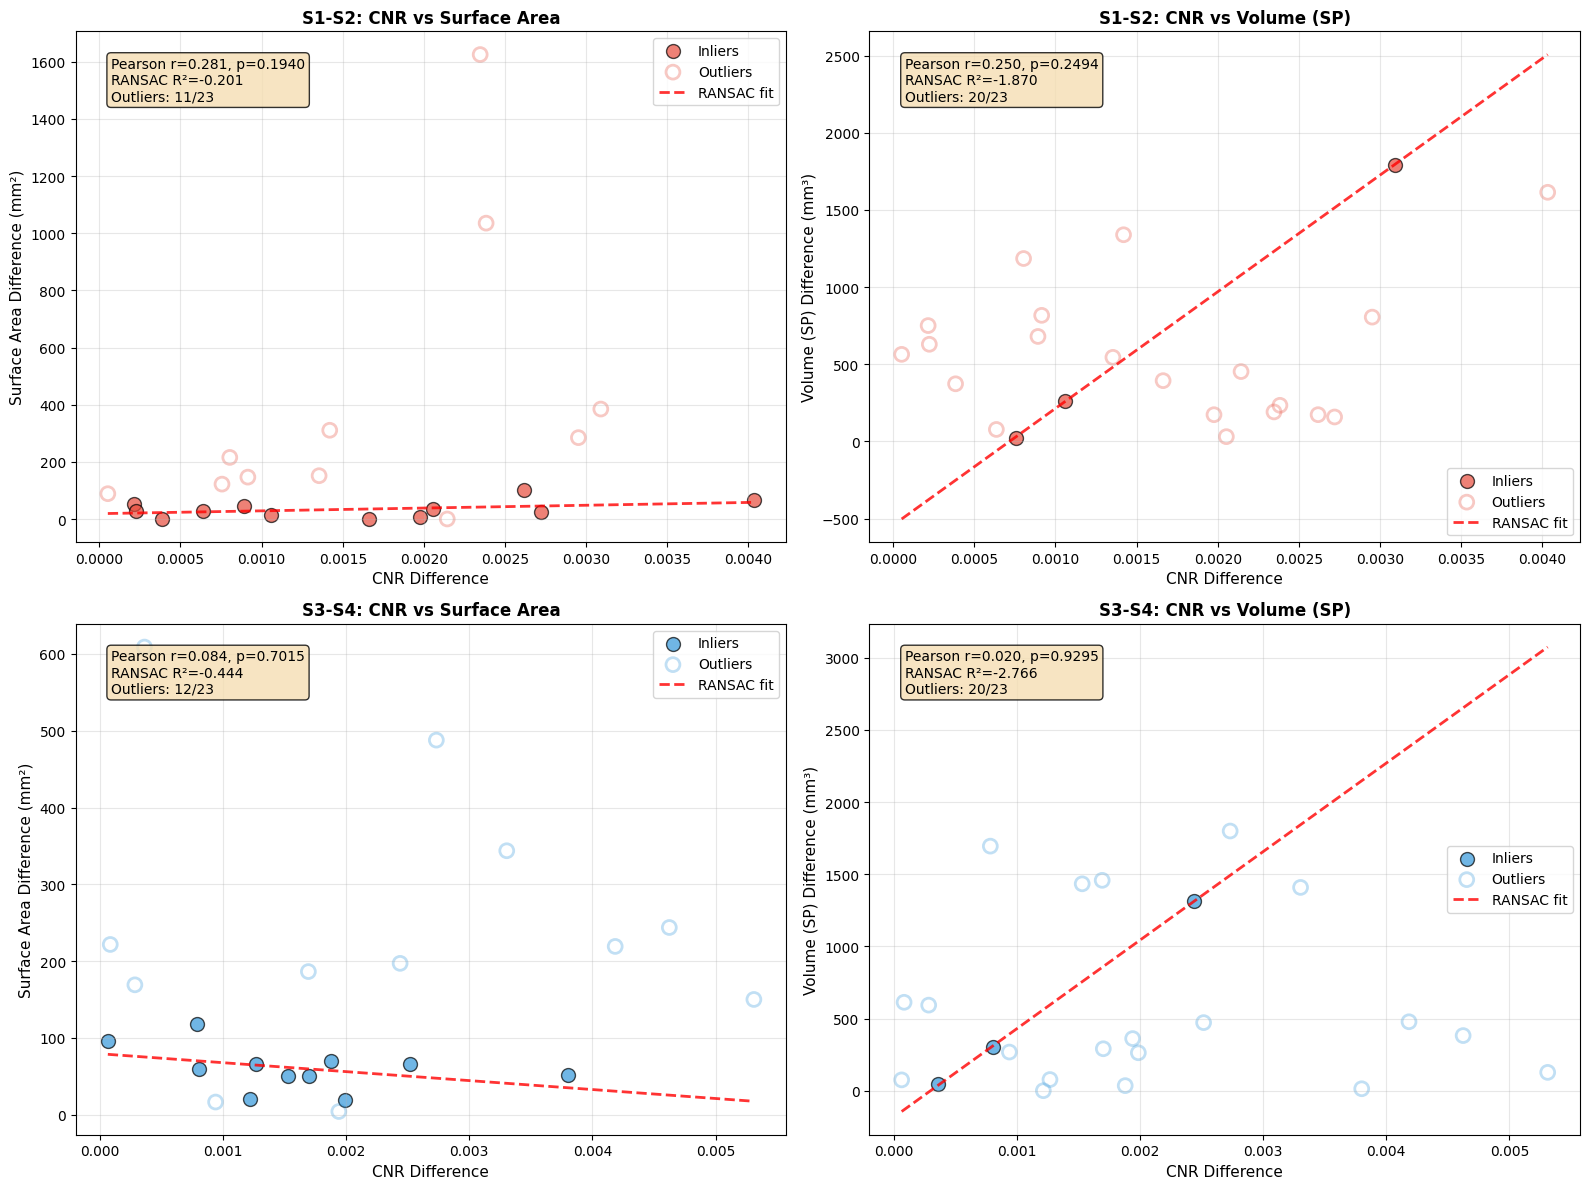

In [10]:
from sklearn.linear_model import RANSACRegressor

def plot_cnr_surface_correlation(split_pair_diffs):
    """
    RANSAC regression: CNR differences vs surface/volume differences.
    Two-panel plot for each split pair (surface left, volume right).
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    split_pairs = ['S1-S2', 'S3-S4']
    colors = {'S1-S2': '#e74c3c', 'S3-S4': '#3498db'}
    
    for row, split_pair in enumerate(split_pairs):
        pair_data = split_pair_diffs[split_pair_diffs['split_pair'] == split_pair].dropna(
            subset=['cnr_diff', 'wm_surface_area_diff', 'abs_diff_sp']
        )
        
        if len(pair_data) < 3:
            for col in range(2):
                axes[row, col].text(0.5, 0.5, f"Insufficient data",
                                   ha='center', va='center', transform=axes[row, col].transAxes)
            continue
        
        x = pair_data['cnr_diff'].values.reshape(-1, 1)
        
        # Left panel: CNR vs Surface Area
        y_surface = pair_data['wm_surface_area_diff'].values
        
        ransac = RANSACRegressor(random_state=42, min_samples=3, residual_threshold=50)
        ransac.fit(x, y_surface)
        
        inlier_mask = ransac.inlier_mask_
        outlier_mask = ~inlier_mask
        
        ax = axes[row, 0]
        
        # Plot inliers and outliers
        ax.scatter(x[inlier_mask], y_surface[inlier_mask], 
                  s=100, alpha=0.7, color=colors[split_pair], edgecolors='black', linewidths=1,
                  label='Inliers')
        ax.scatter(x[outlier_mask], y_surface[outlier_mask],
                  s=100, alpha=0.3, facecolors='none', edgecolors=colors[split_pair], linewidths=2,
                  label='Outliers')
        
        # RANSAC line
        x_line = np.array([x.min(), x.max()]).reshape(-1, 1)
        y_line = ransac.predict(x_line)
        ax.plot(x_line, y_line, 'r--', linewidth=2, alpha=0.8, label='RANSAC fit')
        
        # Pearson r on all data
        r_pearson, p_pearson = stats.pearsonr(x.flatten(), y_surface)
        
        ax.text(0.05, 0.95, 
               f"Pearson r={r_pearson:.3f}, p={p_pearson:.4f}\nRANSAC R²={ransac.score(x, y_surface):.3f}\nOutliers: {outlier_mask.sum()}/{len(pair_data)}",
               transform=ax.transAxes, fontsize=10, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        ax.set_xlabel('CNR Difference', fontsize=11)
        ax.set_ylabel('Surface Area Difference (mm²)', fontsize=11)
        ax.set_title(f'{split_pair}: CNR vs Surface Area', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
        
        # Right panel: CNR vs Volume (SP)
        y_volume = pair_data['abs_diff_sp'].values
        
        ransac_vol = RANSACRegressor(random_state=42, min_samples=3, residual_threshold=10)
        ransac_vol.fit(x, y_volume)
        
        inlier_mask_vol = ransac_vol.inlier_mask_
        outlier_mask_vol = ~inlier_mask_vol
        
        ax = axes[row, 1]
        
        ax.scatter(x[inlier_mask_vol], y_volume[inlier_mask_vol],
                  s=100, alpha=0.7, color=colors[split_pair], edgecolors='black', linewidths=1,
                  label='Inliers')
        ax.scatter(x[outlier_mask_vol], y_volume[outlier_mask_vol],
                  s=100, alpha=0.3, facecolors='none', edgecolors=colors[split_pair], linewidths=2,
                  label='Outliers')
        
        y_line_vol = ransac_vol.predict(x_line)
        ax.plot(x_line, y_line_vol, 'r--', linewidth=2, alpha=0.8, label='RANSAC fit')
        
        r_pearson_vol, p_pearson_vol = stats.pearsonr(x.flatten(), y_volume)
        
        ax.text(0.05, 0.95,
               f"Pearson r={r_pearson_vol:.3f}, p={p_pearson_vol:.4f}\nRANSAC R²={ransac_vol.score(x, y_volume):.3f}\nOutliers: {outlier_mask_vol.sum()}/{len(pair_data)}",
               transform=ax.transAxes, fontsize=10, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        ax.set_xlabel('CNR Difference', fontsize=11)
        ax.set_ylabel('Volume (SP) Difference (mm³)', fontsize=11)
        ax.set_title(f'{split_pair}: CNR vs Volume (SP)', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
    
    plt.tight_layout()
    return fig


fig = plot_cnr_surface_correlation(split_pair_diffs)
plt.show()